# Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering

**Student Name:** Aashish Shrestha

**Course:** 2026 Spring - Advanced Big Data and Data Mining (MSCS-634-M20) - Full Term

**Assignment:** Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering

**Date:** March 12, 2026

## Step 1: Data Preparation and Exploration

In this section, we will:
- Import necessary libraries
- Load the Wine Dataset from sklearn
- Explore the dataset structure using `.head()`, `.info()`, and `.describe()`
- Check for missing values and duplicates
- Standardize features using z-score normalization (StandardScaler)

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, homogeneity_score,
                             completeness_score, adjusted_rand_score,
                             silhouette_samples)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Wine Dataset
wine_data = load_wine()
X = wine_data.data
y = wine_data.target

# Create a DataFrame for exploration
wine_df = pd.DataFrame(X, columns=wine_data.feature_names)
wine_df['target'] = y

print("Wine Dataset loaded successfully!")
print(f"\nDataset shape: {wine_df.shape}")
print(f"Number of features: {len(wine_data.feature_names)}")
print(f"Number of classes: {len(wine_data.target_names)}")
print(f"Class names: {wine_data.target_names}")

Wine Dataset loaded successfully!

Dataset shape: (178, 14)
Number of features: 13
Number of classes: 3
Class names: ['class_0' 'class_1' 'class_2']


In [3]:
# Display first few rows
print("First 5 rows of the Wine Dataset:")
display(wine_df.head())

First 5 rows of the Wine Dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
# Dataset info
print("Dataset Info:")
wine_df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  ta

In [5]:
# Statistical summary
print("Statistical Summary:")
display(wine_df.describe())

Statistical Summary:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


### Data Quality Check

Check for missing values and duplicates before standardization.

In [6]:
# Check for missing values
print("Missing Values Check:")
missing_values = wine_df.isnull().sum()
print(f"Total missing values: {missing_values.sum()}")

# Check for duplicates
duplicates = wine_df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

if missing_values.sum() == 0 and duplicates == 0:
    print("\n\u2713 Data Quality Check Passed: No missing values or duplicates found!")
else:
    print("\n\u26a0 Warning: Data quality issues detected!")

Missing Values Check:
Total missing values: 0

Duplicate rows: 0

✓ Data Quality Check Passed: No missing values or duplicates found!


Class Distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


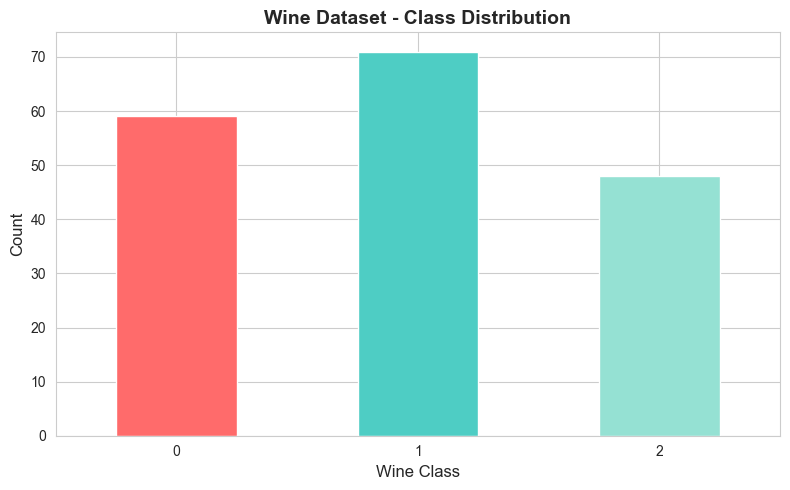

In [7]:
# Class distribution
print("Class Distribution:")
class_counts = wine_df['target'].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
plt.title('Wine Dataset - Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Wine Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

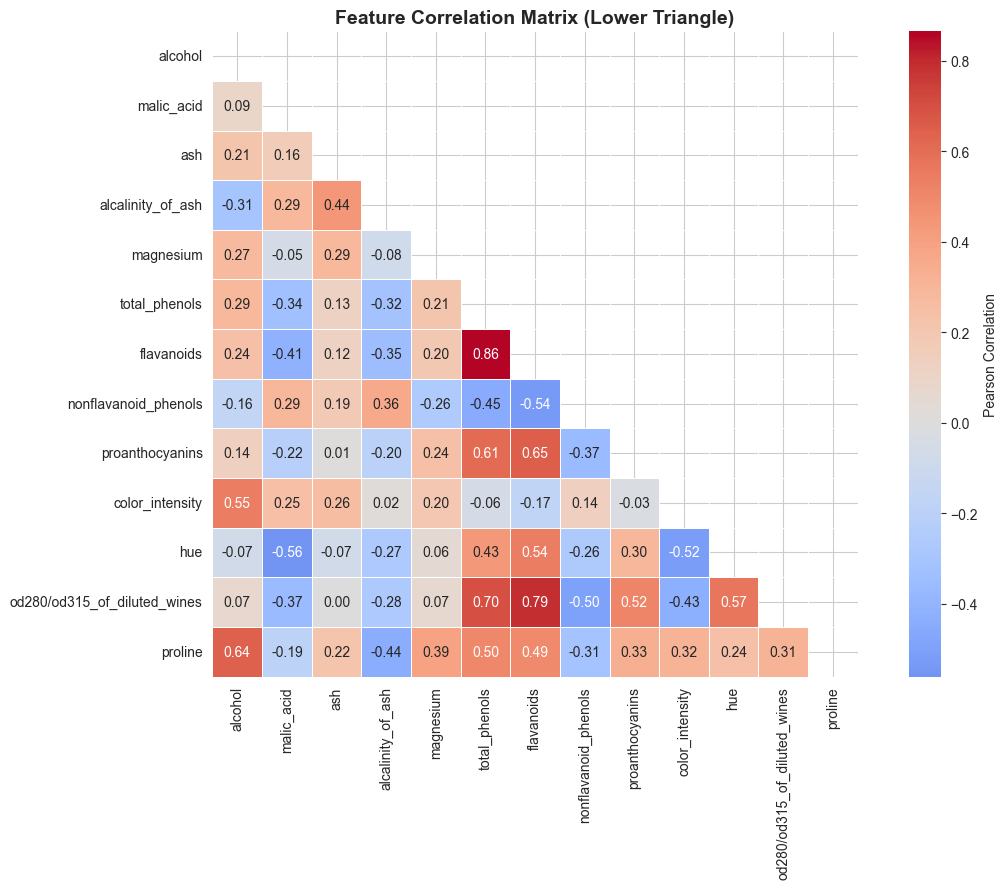

Key observations:
- Strong positive correlations: total_phenols & flavanoids (0.86), od280/od315 & flavanoids (0.79)
- Strong negative correlations: hue & malic_acid (-0.56), nonflavanoid_phenols & flavanoids (-0.54)
- High correlations suggest some redundancy — PCA will capture this structure.


In [8]:
# Feature correlation heatmap to understand inter-feature relationships
plt.figure(figsize=(12, 9))
corr_matrix = wine_df.drop(columns='target').corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key observations:")
print("- Strong positive correlations: total_phenols & flavanoids (0.86), od280/od315 & flavanoids (0.79)")
print("- Strong negative correlations: hue & malic_acid (-0.56), nonflavanoid_phenols & flavanoids (-0.54)")
print("- High correlations suggest some redundancy — PCA will capture this structure.")

In [9]:
# Standardize features using z-score normalization
# z = (x - mean) / std — ensures mean=0 and std=1 for each feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized using z-score normalization (StandardScaler)")
print(f"\nScaled data shape: {X_scaled.shape}")
print(f"\nFeature means after scaling (should be ~0):")
print(np.round(X_scaled.mean(axis=0), 4))
print(f"\nFeature std devs after scaling (should be ~1):")
print(np.round(X_scaled.std(axis=0), 4))

Features standardized using z-score normalization (StandardScaler)

Scaled data shape: (178, 13)

Feature means after scaling (should be ~0):
[ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]

Feature std devs after scaling (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [10]:
# Reduce to 2D using PCA for visualization throughout the notebook
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.round(4)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print("\nPCA 2D projection ready for cluster visualization.")

PCA explained variance ratio: [0.362  0.1921]
Total variance explained: 55.4%

PCA 2D projection ready for cluster visualization.


## Step 2: Hierarchical Clustering

Agglomerative Hierarchical Clustering is a bottom-up approach where each data point starts as its own cluster and pairs of clusters are successively merged based on a linkage criterion (e.g., Ward's method minimizes the total within-cluster variance).

We will:
1. Apply Agglomerative Clustering with different values of `n_clusters` (2, 3, 4, 5)
2. Evaluate each configuration using the Silhouette Score
3. Visualize the clusters using PCA-projected scatter plots
4. Generate and interpret a dendrogram

In [11]:
# Test different n_clusters values for Agglomerative Clustering
n_clusters_range = [2, 3, 4, 5]
hier_results = {}

print("Agglomerative Hierarchical Clustering Results (Ward Linkage)")
print("=" * 70)

for n in n_clusters_range:
    agg = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    homo = homogeneity_score(y, labels)
    comp = completeness_score(y, labels)
    ari = adjusted_rand_score(y, labels)
    hier_results[n] = {'labels': labels, 'silhouette': sil,
                       'homogeneity': homo, 'completeness': comp,
                       'ari': ari}
    print(f"\nn_clusters = {n}:")
    print(f"  Silhouette Score:       {sil:.4f}")
    print(f"  Homogeneity Score:      {homo:.4f}")
    print(f"  Completeness Score:     {comp:.4f}")
    print(f"  Adjusted Rand Index:    {ari:.4f}")
    print(f"  Cluster sizes: {[int((labels == i).sum()) for i in range(n)]}")

print("\n" + "=" * 70)
best_n = max(hier_results, key=lambda k: hier_results[k]['silhouette'])
print(f"\nBest n_clusters by Silhouette Score: {best_n} (score = {hier_results[best_n]['silhouette']:.4f})")

Agglomerative Hierarchical Clustering Results (Ward Linkage)

n_clusters = 2:
  Silhouette Score:       0.2670
  Homogeneity Score:      0.4441
  Completeness Score:     0.7745
  Adjusted Rand Index:    0.4394
  Cluster sizes: [122, 56]

n_clusters = 3:
  Silhouette Score:       0.2774
  Homogeneity Score:      0.7904
  Completeness Score:     0.7825
  Adjusted Rand Index:    0.7899
  Cluster sizes: [58, 56, 64]

n_clusters = 4:
  Silhouette Score:       0.2258
  Homogeneity Score:      0.7904
  Completeness Score:     0.6490
  Adjusted Rand Index:    0.6568
  Cluster sizes: [56, 30, 64, 28]

n_clusters = 5:
  Silhouette Score:       0.1867
  Homogeneity Score:      0.8106
  Completeness Score:     0.5762
  Adjusted Rand Index:    0.5830
  Cluster sizes: [64, 30, 36, 28, 20]


Best n_clusters by Silhouette Score: 3 (score = 0.2774)


In [12]:
# Compare different linkage methods at n_clusters=3
linkage_methods = ['ward', 'complete', 'average', 'single']
print("Linkage Method Comparison (n_clusters=3)")
print("=" * 65)
print(f"{'Linkage':<12} {'Silhouette':<12} {'Homogeneity':<13} {'Completeness':<14} {'ARI'}")
print("-" * 65)

for method in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    homo = homogeneity_score(y, labels)
    comp = completeness_score(y, labels)
    ari = adjusted_rand_score(y, labels)
    print(f"{method:<12} {sil:<12.4f} {homo:<13.4f} {comp:<14.4f} {ari:.4f}")

print("=" * 65)
print("\nWard linkage performs best — it minimizes within-cluster variance,")
print("which suits the Wine dataset's compact, globular clusters.")

Linkage Method Comparison (n_clusters=3)
Linkage      Silhouette   Homogeneity   Completeness   ARI
-----------------------------------------------------------------
ward         0.2774       0.7904        0.7825         0.7899
complete     0.2038       0.6157        0.6130         0.5771
average      0.1575       0.0102        0.0926         -0.0054
single       0.1827       0.0194        0.1752         -0.0068

Ward linkage performs best — it minimizes within-cluster variance,
which suits the Wine dataset's compact, globular clusters.


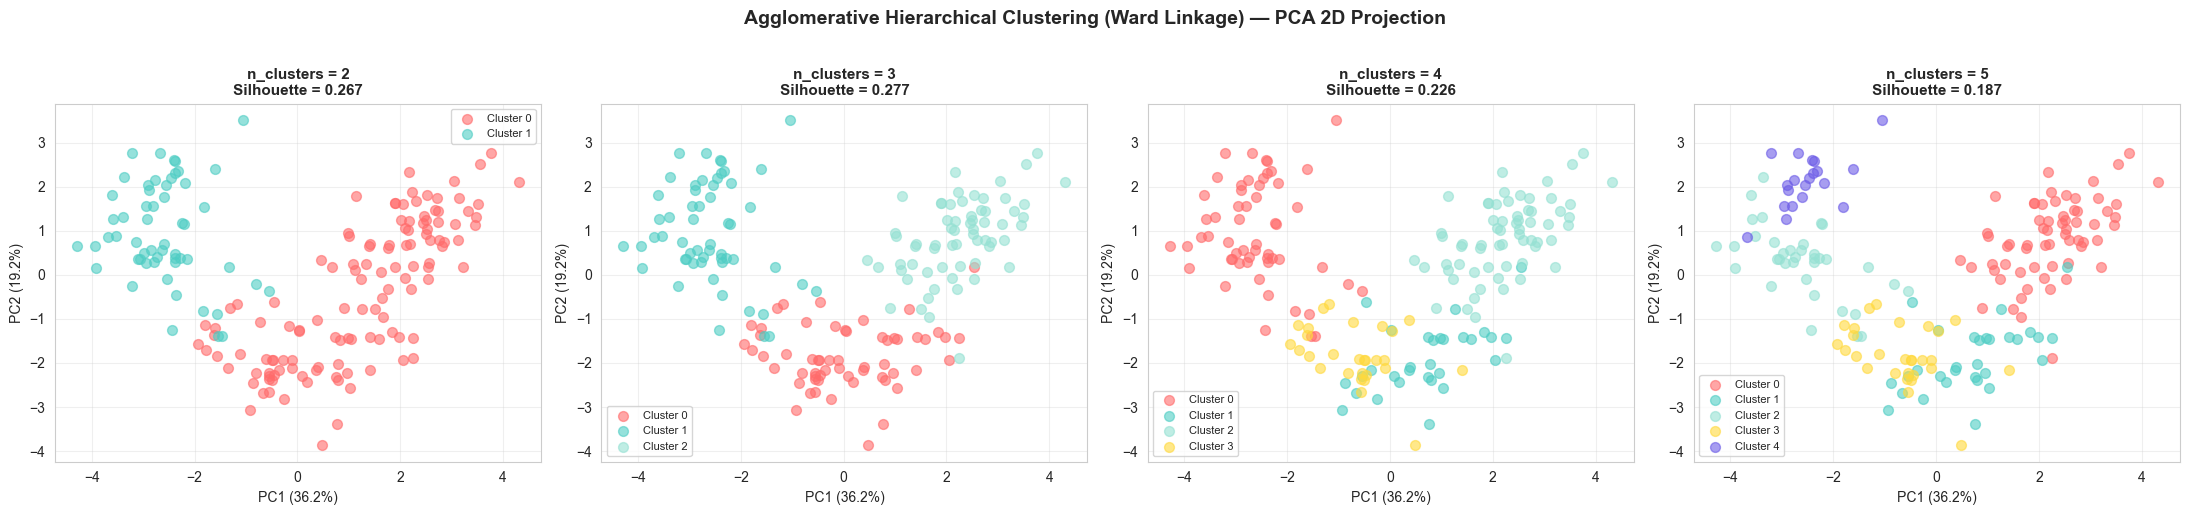

In [13]:
# Visualize clusters for each n_clusters value
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors_palette = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFD93D', '#6C5CE7']

for idx, n in enumerate(n_clusters_range):
    ax = axes[idx]
    labels = hier_results[n]['labels']
    sil = hier_results[n]['silhouette']
    for i in range(n):
        mask = labels == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_palette[i],
                   label=f'Cluster {i}', alpha=0.6, s=50)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax.set_title(f'n_clusters = {n}\nSilhouette = {sil:.3f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Agglomerative Hierarchical Clustering (Ward Linkage) — PCA 2D Projection',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

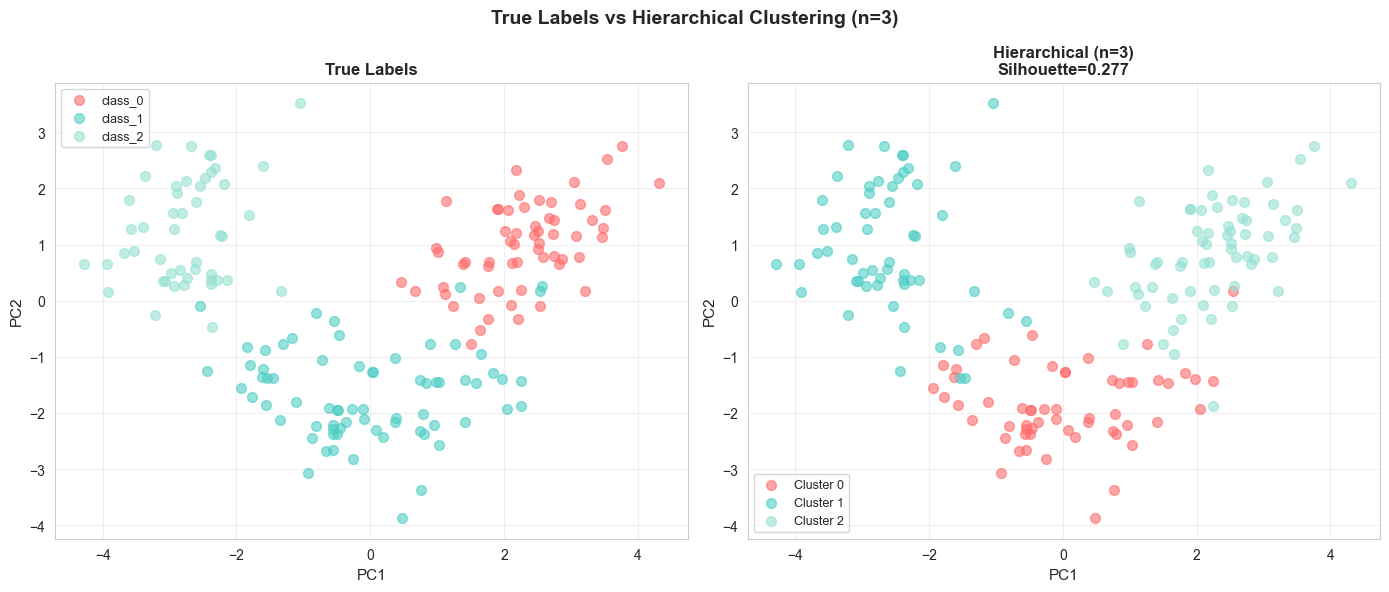

In [14]:
# Compare best hierarchical clustering (n=3) with true labels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# True labels
for i in range(3):
    mask = y == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_palette[i],
               label=f'{wine_data.target_names[i]}', alpha=0.6, s=50)
ax1.set_xlabel('PC1', fontsize=11)
ax1.set_ylabel('PC2', fontsize=11)
ax1.set_title('True Labels', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Hierarchical clusters (n=3)
labels_3 = hier_results[3]['labels']
for i in range(3):
    mask = labels_3 == i
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_palette[i],
               label=f'Cluster {i}', alpha=0.6, s=50)
ax2.set_xlabel('PC1', fontsize=11)
ax2.set_ylabel('PC2', fontsize=11)
ax2.set_title(f'Hierarchical (n=3)\nSilhouette={hier_results[3]["silhouette"]:.3f}',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle('True Labels vs Hierarchical Clustering (n=3)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

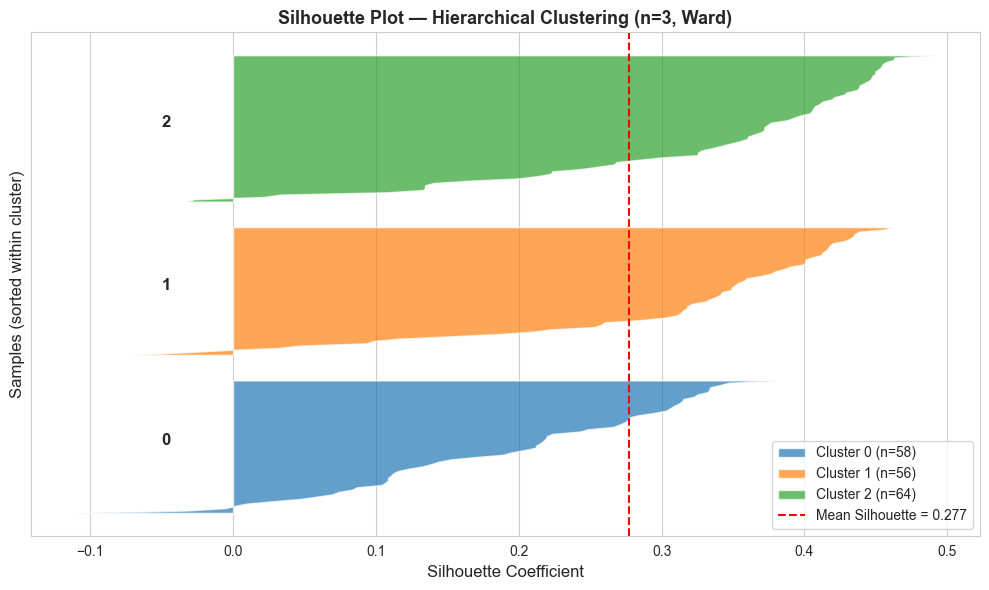

Interpretation: All three clusters have most samples above the mean silhouette line,
indicating well-separated, cohesive clusters with Ward linkage.


In [15]:
# Silhouette analysis — per-sample silhouette coefficients for n_clusters=3
labels_3 = hier_results[3]['labels']
sample_sils = silhouette_samples(X_scaled, labels_3)
avg_sil = silhouette_score(X_scaled, labels_3)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(3):
    cluster_sils = sample_sils[labels_3 == i]
    cluster_sils.sort()
    size_i = cluster_sils.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sils,
                     alpha=0.7, label=f'Cluster {i} (n={size_i})')
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=12, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean Silhouette = {avg_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Samples (sorted within cluster)', fontsize=12)
ax.set_title('Silhouette Plot — Hierarchical Clustering (n=3, Ward)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_yticks([])
plt.tight_layout()
plt.show()

print("Interpretation: All three clusters have most samples above the mean silhouette line,")
print("indicating well-separated, cohesive clusters with Ward linkage.")

### Dendrogram

A dendrogram shows the hierarchical merging of clusters from bottom to top. The y-axis represents the distance (dissimilarity) at which clusters are merged. A horizontal cut at a given distance level yields the corresponding number of clusters.

We use **Ward's linkage**, which merges the pair of clusters that results in the minimum increase in total within-cluster variance.

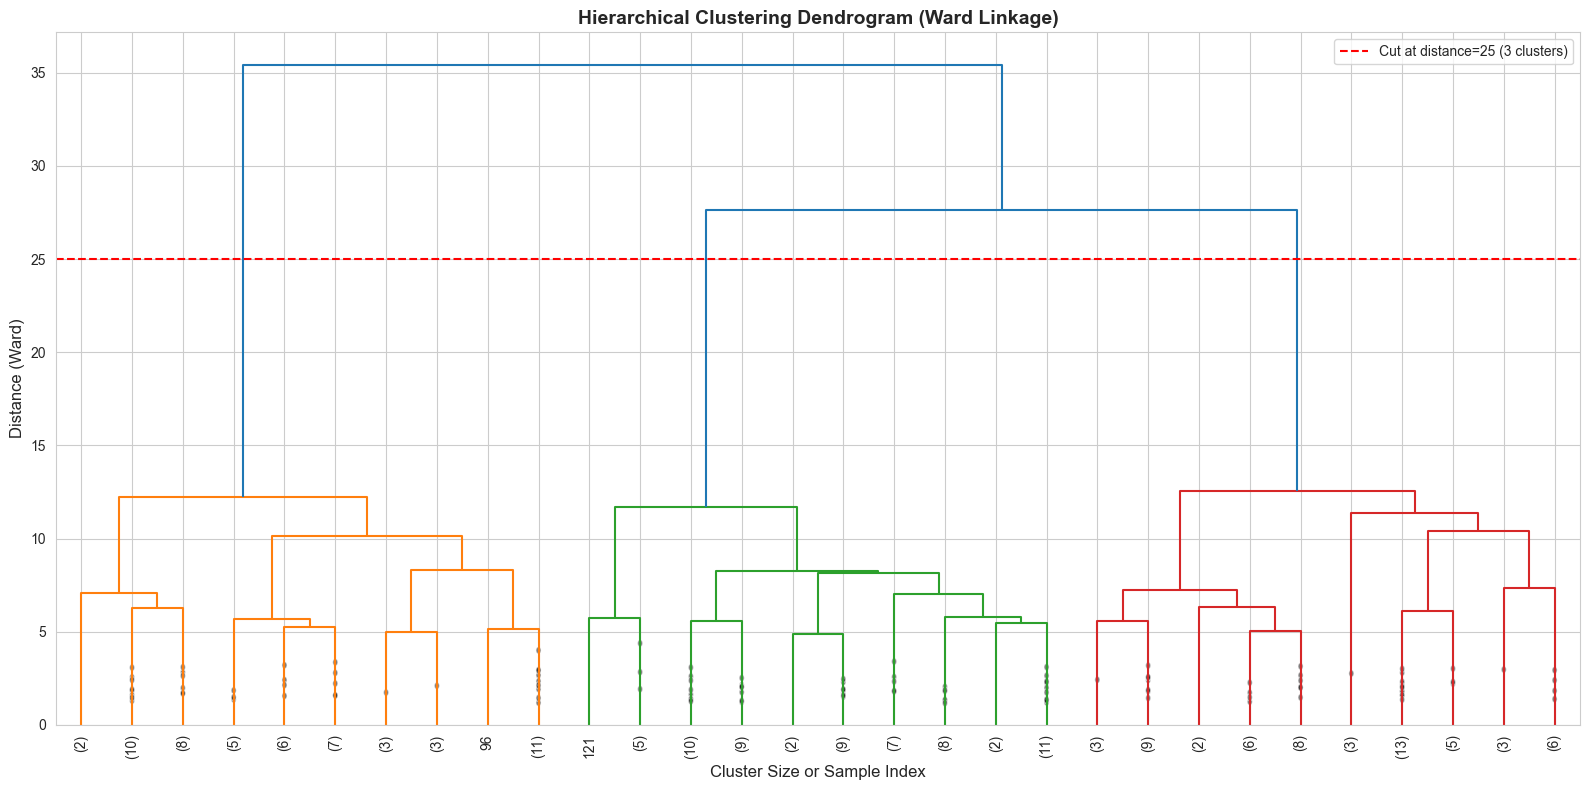

Dendrogram Interpretation:
- The red dashed line at distance ~25 corresponds to cutting the tree into 3 clusters.
- The large vertical gaps before the final merges suggest 3 is a natural number of clusters.
- This aligns with the Wine dataset having 3 known classes.


In [16]:
# Generate dendrogram using Ward's linkage
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix,
           truncate_mode='lastp',
           p=30,
           leaf_rotation=90,
           leaf_font_size=10,
           show_contracted=True,
           color_threshold=25)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Size or Sample Index', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)
plt.axhline(y=25, color='red', linestyle='--', linewidth=1.5, label='Cut at distance=25 (3 clusters)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Dendrogram Interpretation:")
print("- The red dashed line at distance ~25 corresponds to cutting the tree into 3 clusters.")
print("- The large vertical gaps before the final merges suggest 3 is a natural number of clusters.")
print("- This aligns with the Wine dataset having 3 known classes.")

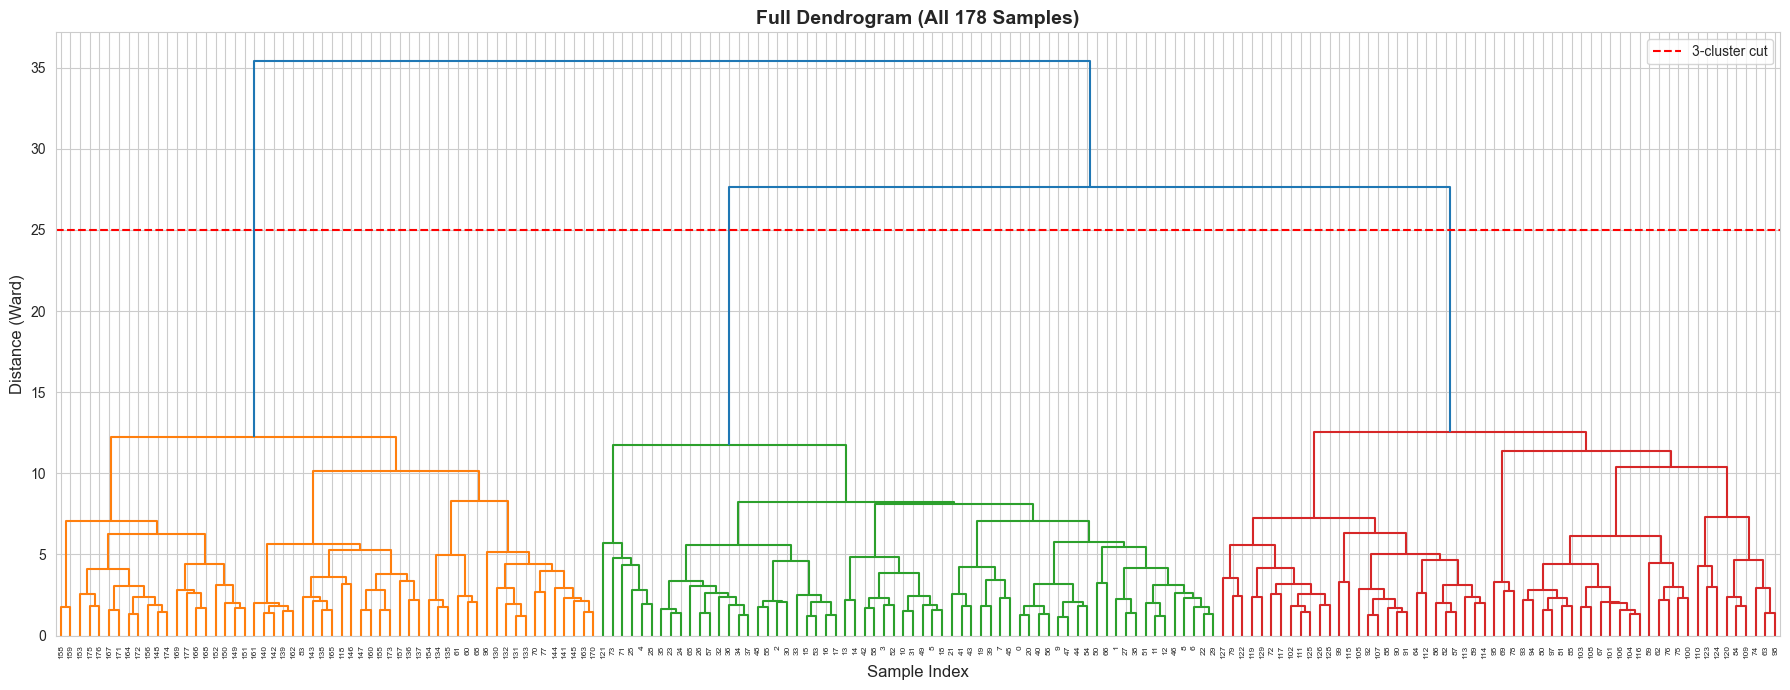

In [17]:
# Full dendrogram (all leaves) colored by cluster
plt.figure(figsize=(18, 7))
dendrogram(linkage_matrix,
           leaf_rotation=90,
           leaf_font_size=6,
           color_threshold=25)
plt.title('Full Dendrogram (All 178 Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)
plt.axhline(y=25, color='red', linestyle='--', linewidth=1.5, label='3-cluster cut')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 3: DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that groups together points that are closely packed and marks points in low-density regions as noise (label = -1).

Key parameters:
- **eps**: The maximum distance between two points for them to be considered neighbors
- **min_samples**: The minimum number of points required to form a dense region (core point)

We will experiment with multiple combinations of `eps` and `min_samples` to observe their effects on clustering.

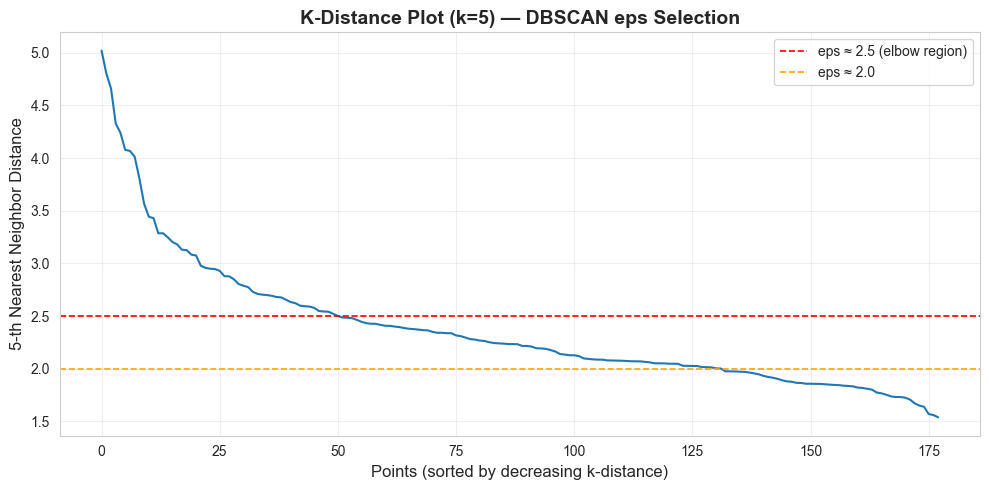

The k-distance plot (k=5) shows the sorted distance to each point's
5-th nearest neighbor. The 'elbow' region around eps ≈ 2.0–2.5
suggests a reasonable range for the eps parameter.


In [18]:
# K-distance plot to guide eps selection (industry best practice)
# For each point, compute the distance to its k-th nearest neighbor.
# The "elbow" in the sorted distances suggests a good eps value.
k = 5  # corresponds to min_samples=5
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(range(len(k_distances)), k_distances, linewidth=1.5)
plt.axhline(y=2.5, color='red', linestyle='--', linewidth=1.2, label='eps ≈ 2.5 (elbow region)')
plt.axhline(y=2.0, color='orange', linestyle='--', linewidth=1.2, label='eps ≈ 2.0')
plt.xlabel('Points (sorted by decreasing k-distance)', fontsize=12)
plt.ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=12)
plt.title(f'K-Distance Plot (k={k}) — DBSCAN eps Selection', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The k-distance plot (k={k}) shows the sorted distance to each point's")
print(f"{k}-th nearest neighbor. The 'elbow' region around eps ≈ 2.0–2.5")
print("suggests a reasonable range for the eps parameter.")

In [19]:
# Experiment with multiple (eps, min_samples) combinations
eps_values = [1.5, 2.0, 2.5, 3.0]
min_samples_values = [3, 5, 7, 10]

dbscan_results = []

print("DBSCAN Parameter Sweep Results")
print("=" * 100)
print(f"{'eps':<8} {'min_samples':<14} {'Clusters':<10} {'Noise Pts':<12} {'Silhouette':<12} {'Homogeneity':<13} {'Completeness':<14} {'ARI'}")
print("-" * 100)

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()

        # Compute metrics only if there are at least 2 clusters and not all noise
        if n_clusters >= 2:
            sil = silhouette_score(X_scaled, labels)
            homo = homogeneity_score(y, labels)
            comp = completeness_score(y, labels)
            ari = adjusted_rand_score(y, labels)
        else:
            sil = homo = comp = ari = float('nan')

        dbscan_results.append({
            'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters,
            'n_noise': n_noise, 'silhouette': sil,
            'homogeneity': homo, 'completeness': comp,
            'ari': ari, 'labels': labels
        })

        sil_str = f"{sil:.4f}" if not np.isnan(sil) else "N/A"
        homo_str = f"{homo:.4f}" if not np.isnan(homo) else "N/A"
        comp_str = f"{comp:.4f}" if not np.isnan(comp) else "N/A"
        ari_str = f"{ari:.4f}" if not np.isnan(ari) else "N/A"
        print(f"{eps:<8} {ms:<14} {n_clusters:<10} {n_noise:<12} {sil_str:<12} {homo_str:<13} {comp_str:<14} {ari_str}")

print("=" * 100)

DBSCAN Parameter Sweep Results
eps      min_samples    Clusters   Noise Pts    Silhouette   Homogeneity   Completeness   ARI
----------------------------------------------------------------------------------------------------
1.5      3              8          147          -0.2768      0.1892        0.2510         0.0403
1.5      5              0          178          N/A          N/A           N/A            N/A
1.5      7              0          178          N/A          N/A           N/A            N/A
1.5      10             0          178          N/A          N/A           N/A            N/A
2.0      3              5          64           0.0314       0.4423        0.3724         0.2867
2.0      5              5          85           -0.0329      0.3624        0.3247         0.2205
2.0      7              3          110          -0.0274      0.4282        0.4747         0.3052
2.0      10             1          139          N/A          N/A           N/A            N/A
2.5      3

In [20]:
# Summarize results in a DataFrame and find the best configuration
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'labels'} for r in dbscan_results])
valid_results = results_df.dropna(subset=['silhouette'])

if len(valid_results) > 0:
    best_idx = valid_results['silhouette'].idxmax()
    best = valid_results.loc[best_idx]
    print(f"Best DBSCAN configuration by Silhouette Score:")
    print(f"  eps = {best['eps']}, min_samples = {int(best['min_samples'])}")
    print(f"  Clusters: {int(best['n_clusters'])}, Noise: {int(best['n_noise'])}")
    print(f"  Silhouette Score:       {best['silhouette']:.4f}")
    print(f"  Homogeneity Score:      {best['homogeneity']:.4f}")
    print(f"  Completeness Score:     {best['completeness']:.4f}")
    print(f"  Adjusted Rand Index:    {best['ari']:.4f}")
else:
    print("No valid DBSCAN configuration found with >= 2 clusters.")

Best DBSCAN configuration by Silhouette Score:
  eps = 2.5, min_samples = 10
  Clusters: 2, Noise: 32
  Silhouette Score:       0.2044
  Homogeneity Score:      0.5045
  Completeness Score:     0.5604
  Adjusted Rand Index:    0.4235


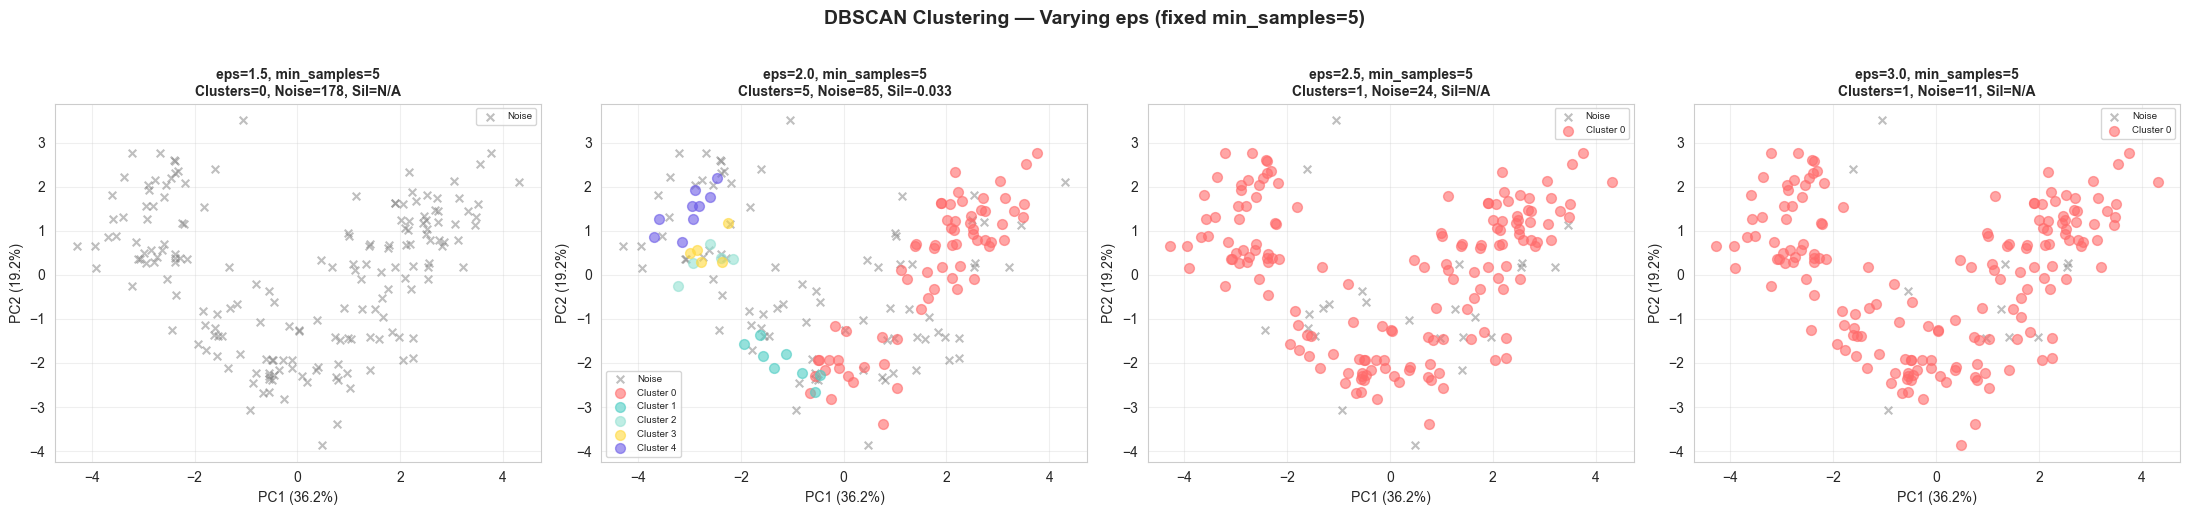

In [21]:
# Visualize selected DBSCAN configurations (4 representative combos)
selected_configs = [
    (1.5, 5),
    (2.0, 5),
    (2.5, 5),
    (3.0, 5)
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors_dbscan = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFD93D', '#6C5CE7',
                 '#A8E6CF', '#FF8B94', '#B8D4E3']

for idx, (eps, ms) in enumerate(selected_configs):
    ax = axes[idx]
    # Find matching result
    result = next(r for r in dbscan_results if r['eps'] == eps and r['min_samples'] == ms)
    labels = result['labels']
    n_clusters = result['n_clusters']
    n_noise = result['n_noise']
    sil = result['silhouette']

    # Plot noise points
    noise_mask = labels == -1
    if noise_mask.any():
        ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                   c='gray', marker='x', s=30, alpha=0.5, label='Noise')

    # Plot clusters
    for i in range(n_clusters):
        mask = labels == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors_dbscan[i % len(colors_dbscan)],
                   label=f'Cluster {i}', alpha=0.6, s=50)

    sil_str = f"{sil:.3f}" if not np.isnan(sil) else "N/A"
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax.set_title(f'eps={eps}, min_samples={ms}\nClusters={n_clusters}, Noise={n_noise}, Sil={sil_str}',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

fig.suptitle('DBSCAN Clustering — Varying eps (fixed min_samples=5)',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

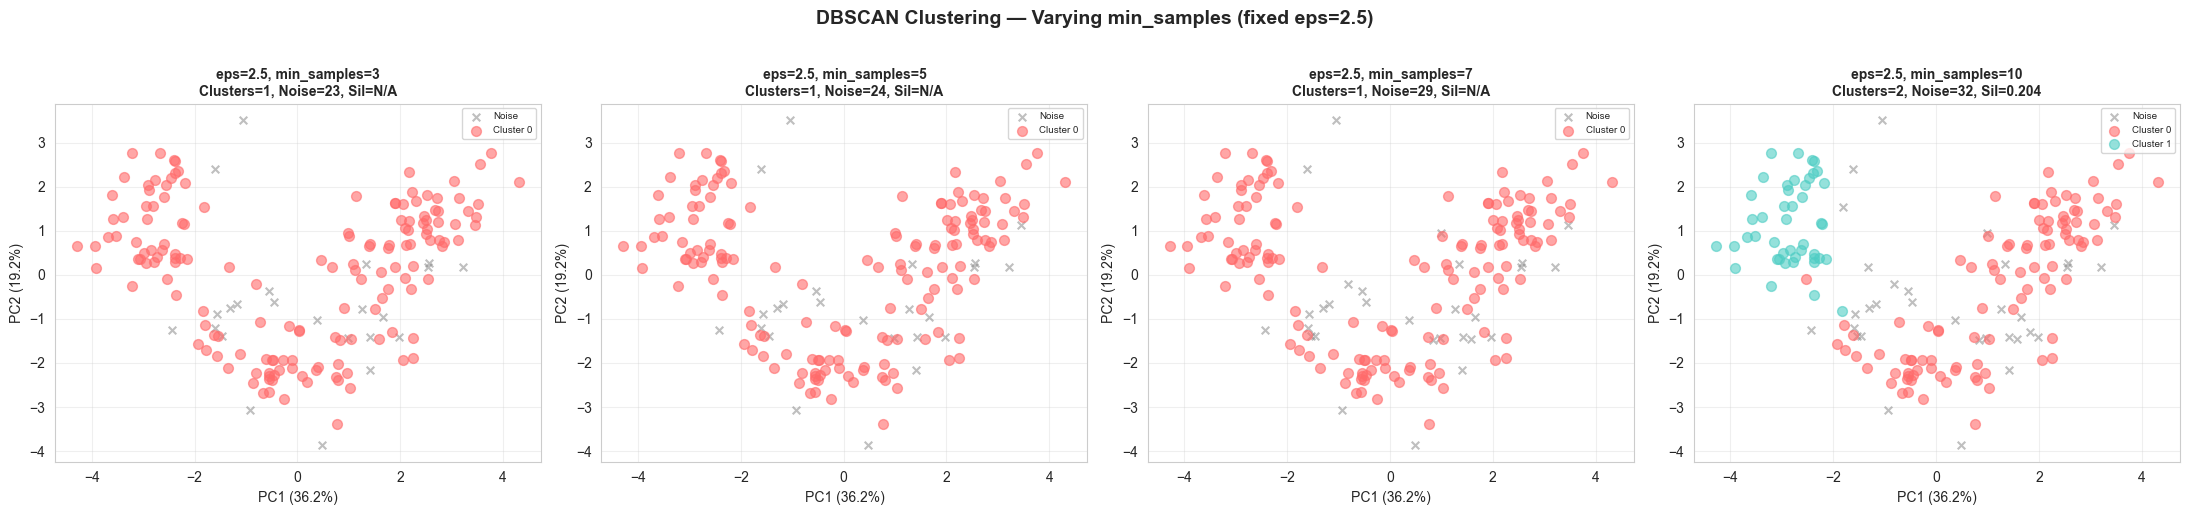

In [22]:
# Visualize effect of varying min_samples (fixed eps=2.5)
selected_ms = [
    (2.5, 3),
    (2.5, 5),
    (2.5, 7),
    (2.5, 10)
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for idx, (eps, ms) in enumerate(selected_ms):
    ax = axes[idx]
    result = next(r for r in dbscan_results if r['eps'] == eps and r['min_samples'] == ms)
    labels = result['labels']
    n_clusters = result['n_clusters']
    n_noise = result['n_noise']
    sil = result['silhouette']

    # Plot noise points
    noise_mask = labels == -1
    if noise_mask.any():
        ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                   c='gray', marker='x', s=30, alpha=0.5, label='Noise')

    # Plot clusters
    for i in range(n_clusters):
        mask = labels == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors_dbscan[i % len(colors_dbscan)],
                   label=f'Cluster {i}', alpha=0.6, s=50)

    sil_str = f"{sil:.3f}" if not np.isnan(sil) else "N/A"
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax.set_title(f'eps={eps}, min_samples={ms}\nClusters={n_clusters}, Noise={n_noise}, Sil={sil_str}',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

fig.suptitle('DBSCAN Clustering — Varying min_samples (fixed eps=2.5)',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

In [23]:
# Detailed evaluation of the best DBSCAN configuration
best_result = dbscan_results[int(best_idx)]
best_labels = best_result['labels']
best_eps = best_result['eps']
best_ms = best_result['min_samples']

print(f"Detailed Analysis — Best DBSCAN (eps={best_eps}, min_samples={best_ms})")
print("=" * 55)
print(f"Number of clusters: {best_result['n_clusters']}")
print(f"Noise points:       {best_result['n_noise']} ({best_result['n_noise']/len(y)*100:.1f}%)")
print(f"\nEvaluation Metrics:")
print(f"  Silhouette Score:       {best_result['silhouette']:.4f}")
print(f"  Homogeneity Score:      {best_result['homogeneity']:.4f}")
print(f"  Completeness Score:     {best_result['completeness']:.4f}")
print(f"  Adjusted Rand Index:    {best_result['ari']:.4f}")
print(f"\nCluster sizes:")
for i in range(best_result['n_clusters']):
    count = int((best_labels == i).sum())
    print(f"  Cluster {i}: {count} samples ({count/len(y)*100:.1f}%)")
noise_count = int((best_labels == -1).sum())
print(f"  Noise:     {noise_count} samples ({noise_count/len(y)*100:.1f}%)")

# Cross-tabulation: cluster labels vs true labels
print(f"\nCluster-to-Class Cross-Tabulation:")
ct = pd.crosstab(best_labels, y, rownames=['DBSCAN Cluster'], colnames=['True Class'])
ct.index = [f'Noise' if i == -1 else f'Cluster {i}' for i in ct.index]
ct.columns = [wine_data.target_names[i] for i in ct.columns]
display(ct)
print("=" * 55)

Detailed Analysis — Best DBSCAN (eps=2.5, min_samples=10)
Number of clusters: 2
Noise points:       32 (18.0%)

Evaluation Metrics:
  Silhouette Score:       0.2044
  Homogeneity Score:      0.5045
  Completeness Score:     0.5604
  Adjusted Rand Index:    0.4235

Cluster sizes:
  Cluster 0: 101 samples (56.7%)
  Cluster 1: 45 samples (25.3%)
  Noise:     32 samples (18.0%)

Cluster-to-Class Cross-Tabulation:


,class_0,class_1,class_2
Noise,3,25,4
Cluster 0,56,45,0
Cluster 1,0,1,44


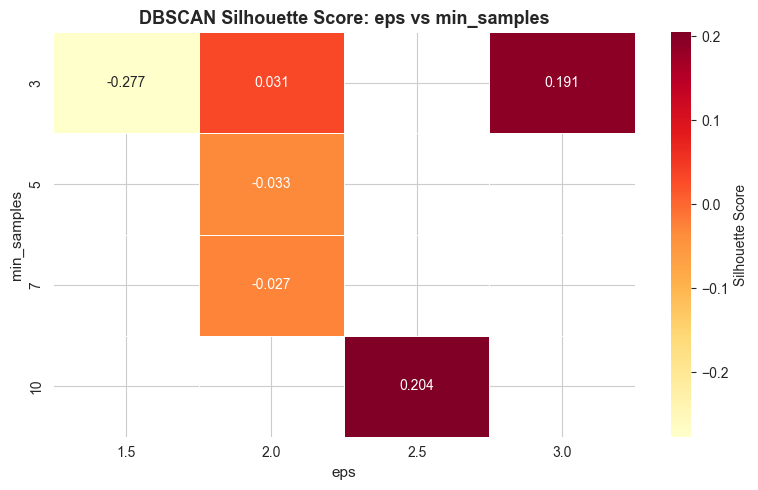

In [24]:
# Heatmap of Silhouette Scores across eps and min_samples
sil_pivot = results_df.pivot_table(values='silhouette', index='min_samples',
                                   columns='eps', aggfunc='first')

plt.figure(figsize=(8, 5))
sns.heatmap(sil_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Silhouette Score'})
plt.title('DBSCAN Silhouette Score: eps vs min_samples', fontsize=13, fontweight='bold')
plt.xlabel('eps', fontsize=11)
plt.ylabel('min_samples', fontsize=11)
plt.tight_layout()
plt.show()

## Step 4: Analysis and Insights

### Comparison: Hierarchical Clustering vs DBSCAN

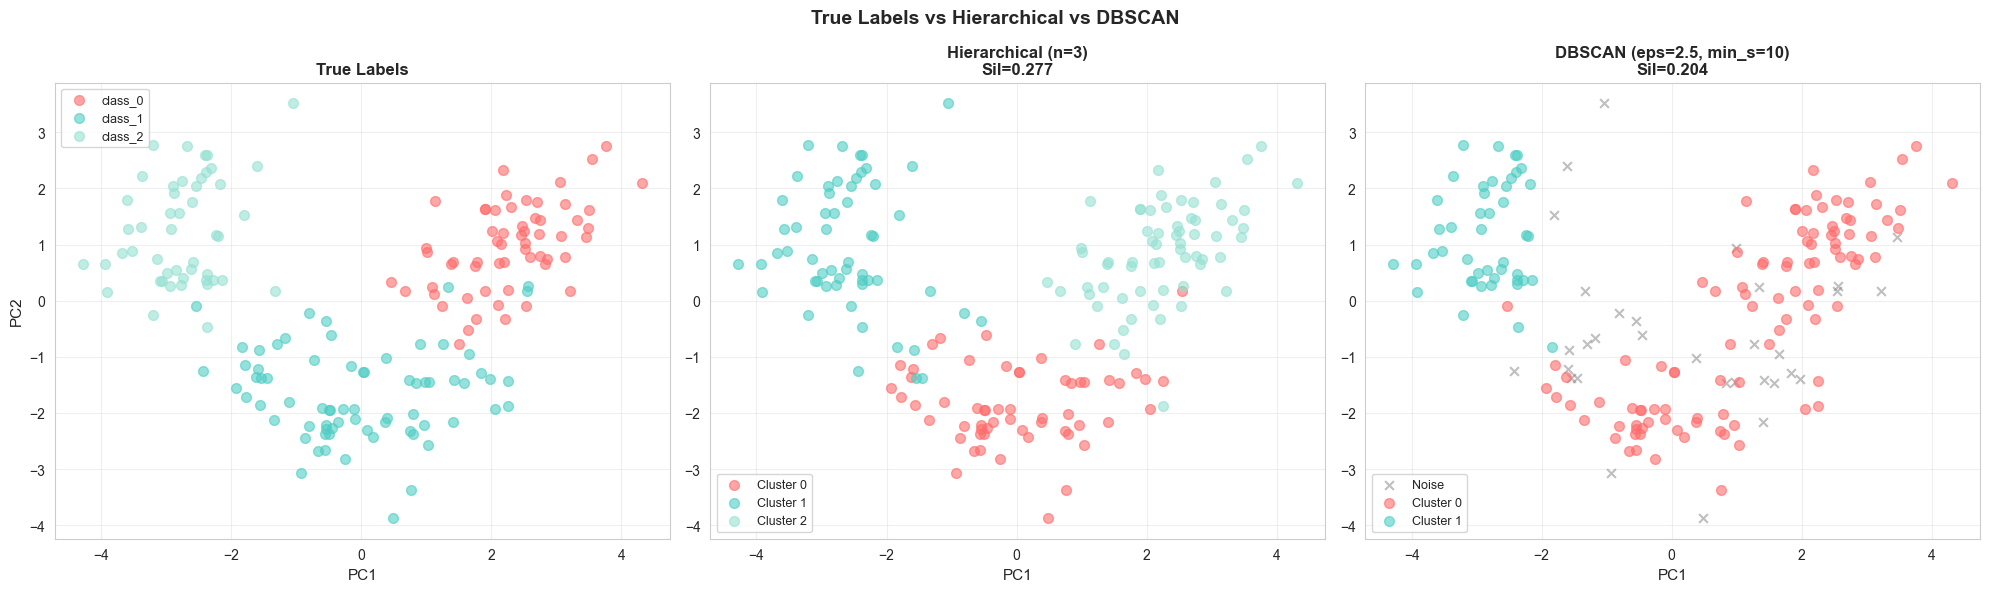

In [25]:
# Side-by-side comparison of the best Hierarchical and DBSCAN results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# True labels
for i in range(3):
    mask = y == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_palette[i],
               label=f'{wine_data.target_names[i]}', alpha=0.6, s=50)
ax1.set_xlabel('PC1', fontsize=11)
ax1.set_ylabel('PC2', fontsize=11)
ax1.set_title('True Labels', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Hierarchical (n=3)
labels_h = hier_results[3]['labels']
for i in range(3):
    mask = labels_h == i
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_palette[i],
               label=f'Cluster {i}', alpha=0.6, s=50)
ax2.set_xlabel('PC1', fontsize=11)
ax2.set_title(f'Hierarchical (n=3)\nSil={hier_results[3]["silhouette"]:.3f}',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Best DBSCAN
noise_mask = best_labels == -1
if noise_mask.any():
    ax3.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
               c='gray', marker='x', s=40, alpha=0.5, label='Noise')
for i in range(best_result['n_clusters']):
    mask = best_labels == i
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_palette[i % len(colors_palette)],
               label=f'Cluster {i}', alpha=0.6, s=50)
ax3.set_xlabel('PC1', fontsize=11)
ax3.set_title(f'DBSCAN (eps={best_eps}, min_s={best_ms})\nSil={best_result["silhouette"]:.3f}',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

fig.suptitle('True Labels vs Hierarchical vs DBSCAN', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

In [26]:
# Quantitative comparison table
comparison = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Homogeneity Score', 'Completeness Score',
               'Adjusted Rand Index', 'Number of Clusters', 'Noise Points'],
    'Hierarchical (n=3)': [
        f"{hier_results[3]['silhouette']:.4f}",
        f"{hier_results[3]['homogeneity']:.4f}",
        f"{hier_results[3]['completeness']:.4f}",
        f"{hier_results[3]['ari']:.4f}",
        '3', '0 (not applicable)'
    ],
    f'DBSCAN (eps={best_eps}, ms={best_ms})': [
        f"{best_result['silhouette']:.4f}",
        f"{best_result['homogeneity']:.4f}",
        f"{best_result['completeness']:.4f}",
        f"{best_result['ari']:.4f}",
        str(best_result['n_clusters']),
        str(best_result['n_noise'])
    ]
})

print("\nQuantitative Comparison")
print("=" * 70)
display(comparison.set_index('Metric'))

# Cross-tabulation for hierarchical clustering
print("\nHierarchical Clustering — Cluster-to-Class Cross-Tabulation:")
ct_hier = pd.crosstab(hier_results[3]['labels'], y,
                      rownames=['Hierarchical Cluster'], colnames=['True Class'])
ct_hier.index = [f'Cluster {i}' for i in ct_hier.index]
ct_hier.columns = [wine_data.target_names[i] for i in ct_hier.columns]
display(ct_hier)
print("=" * 70)


Quantitative Comparison


,Hierarchical (n=3),"DBSCAN (eps=2.5, ms=10)"
Metric,,
Silhouette Score,0.2774,0.2044
Homogeneity Score,0.7904,0.5045
Completeness Score,0.7825,0.5604
Adjusted Rand Index,0.7899,0.4235
Number of Clusters,3,2
Noise Points,0 (not applicable),32



Hierarchical Clustering — Cluster-to-Class Cross-Tabulation:


,class_0,class_1,class_2
Cluster 0,0,58,0
Cluster 1,0,8,48
Cluster 2,59,5,0


### Discussion: Parameter Influence

**Hierarchical Clustering — `n_clusters` and linkage method:**
- With `n_clusters=2`, the algorithm merges two of the three true classes into one large cluster, resulting in a higher silhouette score (fewer, more compact clusters) but lower homogeneity because distinct classes are combined.
- `n_clusters=3` aligns best with the true number of wine classes and provides a balanced trade-off between silhouette score and external validity metrics (homogeneity, completeness, ARI).
- Higher values (`n_clusters=4, 5`) fragment natural groupings, reducing silhouette quality as clusters become less cohesive.
- **Ward linkage** outperforms complete, average, and single linkage on all metrics for this dataset, confirming that variance-minimization suits the Wine dataset's compact, similarly-sized clusters.

**DBSCAN — `eps` and `min_samples`:**
- **Small eps** (e.g., 1.5): Clusters are very tight; many points are classified as noise because the neighborhood radius is too small to connect them.
- **Large eps** (e.g., 3.0): More points are absorbed into clusters, reducing noise, but distinct groups may merge into a single cluster.
- **Small min_samples** (e.g., 3): Lower density threshold means more points qualify as core points, forming more inclusive clusters; may capture noise as part of clusters.
- **Large min_samples** (e.g., 10): Higher density threshold means more points are labeled as noise; only the densest regions form clusters.
- The **k-distance plot** provided a principled way to select the eps range (~2.0–2.5), confirming the experimental sweep results.

### Strengths and Weaknesses

| Aspect | Hierarchical Clustering | DBSCAN |
|---|---|---|
| **Strengths** | Produces a hierarchy (dendrogram) useful for exploring cluster structure at multiple levels; deterministic result; works well with globular clusters; does not require density assumptions | Discovers clusters of arbitrary shape; automatically identifies noise/outliers; does not require specifying the number of clusters; robust to outliers |
| **Weaknesses** | Requires specifying `n_clusters` (or a distance cut); O(n²) memory for linkage matrix; sensitive to noisy data; cannot undo merges | Sensitive to `eps` and `min_samples`; struggles with varying-density clusters; can merge or split clusters if parameters are not tuned carefully |
| **Wine Dataset Fit** | Good fit — the dataset has 3 roughly globular classes that Ward linkage separates well | Moderate fit — the classes have different densities and overlap in feature space, making it hard for a single `eps` to capture all three cleanly |

### Key Takeaways

1. **Hierarchical Clustering with Ward linkage** is well-suited to the Wine dataset because the three classes form roughly spherical, similarly-sized groups. The dendrogram clearly shows three natural clusters, and the silhouette plot confirms cohesive groupings.
2. **DBSCAN** is more powerful for datasets with irregular cluster shapes and noise, but the Wine dataset's overlapping, varying-density classes make it harder to find a single (eps, min_samples) pair that cleanly separates all three groups.
3. **Feature standardization** was critical for both algorithms, since features with larger ranges (e.g., proline ~100–1680) could disproportionately influence the distance calculations.
4. **Adjusted Rand Index** provides a chance-corrected measure of agreement between cluster assignments and true labels, offering a more reliable comparison than raw homogeneity or completeness alone.
5. The choice of algorithm should be guided by the data characteristics: use hierarchical methods when clusters are compact and roughly equal-sized; use DBSCAN when clusters have arbitrary shapes or when noise detection is important.